# Multimodal Retrieval-Augmented Generation System

Unified retrieval across text, code, and images with hybrid retrieval, reranking, and evaluation-driven design.

In [1]:
import sys
from pathlib import Path

# Set dataset BEFORE any imports
import os
os.environ['RAG_DATASET'] = 'btp'

from config.settings import Config
Config.DATASET = 'btp'

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from config.settings import Config

Config.DATASET = 'sample'

## Data Processing

Chunking splits long documents and code into retrieval-friendly units while preserving section/function context.

In [3]:
from pathlib import Path
from time import perf_counter

from chunking.text_chunker import chunk_text_file
from chunking.code_chunker import split_code_by_functions
from config.settings import get_path

data_root = Path(get_path('data'))
text_dir = data_root / 'raw' / 'text'
code_dir = data_root / 'raw' / 'code'
processed_dir = data_root / 'processed'
chunked_text_file = processed_dir / 'chunked_text.json'
chunked_code_file = processed_dir / 'chunked_code.json'

start = perf_counter()

if chunked_text_file.exists() and chunked_code_file.exists():
    print('Chunking skipped: processed chunk files already exist.')
else:
    if text_dir.exists() and not chunked_text_file.exists():
        for text_file in sorted(text_dir.glob('*.txt')):
            chunk_text_file(text_file)

    if code_dir.exists() and not chunked_code_file.exists():
        for code_file in sorted(code_dir.glob('*.py')):
            split_code_by_functions(code_file)

print(f'Chunking time: {perf_counter() - start:.2f}s')

Chunking skipped: processed chunk files already exist.
Chunking time: 0.00s


## Embeddings and Indexing

Embeddings map text/code/images into dense vectors. FAISS indexes those vectors for fast nearest-neighbor retrieval.

In [4]:
import os
from pathlib import Path
from time import perf_counter

import build_and_test_indexes
from config.settings import get_path

os.chdir(PROJECT_ROOT)

index_dir = Path(PROJECT_ROOT) / get_path('indexes')
required = [
    index_dir / 'faiss_text.index',
    index_dir / 'faiss_text_idmap.json',
    index_dir / 'faiss_code.index',
    index_dir / 'faiss_code_idmap.json',
    index_dir / 'faiss_image.index',
    index_dir / 'faiss_image_idmap.json',
]

if all(p.exists() for p in required):
    print(f'Indexes already exist in: {index_dir}')
    print('Skipping embedding + indexing cell.')
else:
    print('Missing one or more index files. Running embedding + indexing...')
    start = perf_counter()
    build_and_test_indexes.main()
    print(f'Indexing time: {perf_counter() - start:.2f}s')

Indexes already exist in: C:\Projects\P2\indexes
Skipping embedding + indexing cell.


## Evaluation

Evaluation uses standard retrieval metrics:
- Precision@k
- Recall@k
- NDCG
- MRR

In [5]:
import json
import os
from pathlib import Path
from time import perf_counter

import compute_hybrid_metrics
import compute_reranked_metrics
import compute_semantic_metrics
from config.settings import get_path

os.chdir(PROJECT_ROOT)

data_dir = Path(PROJECT_ROOT) / get_path("data")
index_dir = Path(PROJECT_ROOT) / get_path("indexes")
queries_path = data_dir / "processed" / "evaluation_queries.json"

queries = json.loads(queries_path.read_text(encoding="utf-8"))
idmaps = {
    "text": set(json.loads((index_dir / "faiss_text_idmap.json").read_text(encoding="utf-8"))),
    "code": set(json.loads((index_dir / "faiss_code_idmap.json").read_text(encoding="utf-8"))),
    "image": set(json.loads((index_dir / "faiss_image_idmap.json").read_text(encoding="utf-8"))),
}

invalid = []
for i, q in enumerate(queries, start=1):
    modality = q["modality"].lower()
    bad_ids = [rid for rid in q.get("relevant_ids", []) if rid not in idmaps[modality]]
    if bad_ids:
        invalid.append({"qid": i, "modality": modality, "invalid_ids": bad_ids})

print(f"Loaded queries: {len(queries)}")
print(f"Invalid relevant_id rows: {len(invalid)}")
if invalid:
    for row in invalid[:5]:
        print(row)
    raise ValueError("Found invalid relevant_ids. Fix them before evaluation.")

start = perf_counter()
semantic_results = compute_semantic_metrics.main()
hybrid_results = compute_hybrid_metrics.main()
reranked_results = compute_reranked_metrics.main()
print(f"Evaluation time: {perf_counter() - start:.2f}s")

METRIC_RESULTS = {
    "semantic": semantic_results,
    "hybrid": hybrid_results,
    "reranked": reranked_results,
}

Loaded queries: 8
Invalid relevant_id rows: 0

Loaded 8 evaluation queries.

Loading FAISS indexes
[FaissIndex] Loaded 66 vector(s) from faiss_text.index  |  faiss_text_idmap.json
[FaissIndex] Loaded 44 vector(s) from faiss_code.index  |  faiss_code_idmap.json
[FaissIndex] Loaded 10 vector(s) from faiss_image.index  |  faiss_image_idmap.json

Loading embedders
[TextEmbedder] Loading 'BAAI/bge-small-en' on cpu ...
[TextEmbedder] Ready. Embedding dim: 384
[CodeEmbedder] Loading 'microsoft/codebert-base' on cpu ...
[CodeEmbedder] Ready. Embedding dim: 768
[ImageEmbedder] Loading 'openai/clip-vit-base-patch32' on cpu ...
[ImageEmbedder] Ready. Embedding dim: 512

Per-query metrics  (P@3 | R@5 | NDCG@5)

  #    Query                                           Mod      P@3    R@5   NDCG@5    GT
1    How does KMeans++ improve centroid initiali...  text   1.000  1.000    1.000     3
2    What is the effect of eps in DBSCAN?            text   1.000  1.000    1.000     3
3    How do you choose th

Code embedding batches:   0%|          | 0/1 [00:00<?, ?batch/s]

5    Example of DBSCAN eps parameter tuning in P...  code   0.667  1.000    0.920     2


Code embedding batches:   0%|          | 0/1 [00:00<?, ?batch/s]

6    How to compute ROC curve using sklearn          code   0.333  0.500    0.613     2
7    DBSCAN clustering with noise points             image  1.000  1.000    1.000     3
8    ROC curve visualization example                 image  0.333  1.000    1.000     1

Global metrics

Evaluated queries (with ground truth): 8 / 8

Metric                            Value
Mean Precision@3                 0.7083
Mean Recall@5                    0.8958
Mean NDCG@5                      0.8740
MRR (over top-5)                 0.9375



Loaded 8 evaluation queries from evaluation_queries.json

[HybridSearchEngine] Loading FAISS indexes ...
[FaissIndex] Loaded 66 vector(s) from faiss_text.index  |  faiss_text_idmap.json
[FaissIndex] Loaded 44 vector(s) from faiss_code.index  |  faiss_code_idmap.json
[FaissIndex] Loaded 10 vector(s) from faiss_image.index  |  faiss_image_idmap.json
[HybridSearchEngine] Loading embedders ...
[TextEmbedder] Loading 'BAAI/bge-small-en' on cpu ...
[TextEmbedder] Ready. E

...

6    How to compute ROC curve using sklearn          code   0.000  0.500    0.237     2
7    DBSCAN clustering with noise points             image  1.000  1.000    1.000     3
8    ROC curve visualization example                 image  0.333  1.000    1.000     1

Global metrics  (hybrid retrieval)

Evaluated queries (with ground truth): 8 / 8

Metric                            Value
Mean Precision@3                 0.4167
Mean Recall@5                    0.7500
Mean NDCG@5                      0.6348
MRR (over top-5)                 0.6604



Compute Reranked Retrieval Metrics

Setup: loading evaluation data
Loaded evaluation queries: 8
Loaded FAISS text index vectors: 66
Loaded FAISS code index vectors: 44
Loaded FAISS image index vectors: 10
Loaded text chunks: 528
Loaded code chunks: 352

Setup: instantiating embedders and reranker
[TextEmbedder] Loading 'BAAI/bge-small-en' on cpu ...
[TextEmbedder] Ready. Embedding dim: 384
[CodeEmbedder] Loading 'microsoft/codebert-base' on cpu .

Code embedding batches:   0%|          | 0/1 [00:00<?, ?batch/s]

Selection mode: code metadata-boosted + query filter (no reranking)
Precision@3: 0.3333
Recall@5: 0.5000
NDCG@5: 0.6131
MRR: 1.0000

Query ID: Q6
Modality: code
Query: How to compute ROC curve using sklearn


Code embedding batches:   0%|          | 0/1 [00:00<?, ?batch/s]

Selection mode: code metadata-boosted + query filter (no reranking)
Precision@3: 0.3333
Recall@5: 0.5000
NDCG@5: 0.6131
MRR: 1.0000

Query ID: Q7
Modality: image
Query: DBSCAN clustering with noise points
Selection mode: image semantic
Precision@3: 1.0000
Recall@5: 1.0000
NDCG@5: 1.0000
MRR: 1.0000

Query ID: Q8
Modality: image
Query: ROC curve visualization example
Selection mode: image semantic
Precision@3: 0.3333
Recall@5: 1.0000
NDCG@5: 1.0000
MRR: 1.0000

Global metrics
Mean Precision@3: 0.5417
Mean Recall@5: 0.7917
Mean NDCG@5: 0.8150
Mean MRR: 1.0000

Per-query results

Query ID: Q1
Precision@3: 1.0000
Recall@5: 1.0000
NDCG@5: 1.0000
Top-3 sources: text_027, text_016, text_026

Query ID: Q2
Precision@3: 0.6667
Recall@5: 0.6667
NDCG@5: 0.7654
Top-3 sources: text_010, text_007, text_000

Query ID: Q3
Precision@3: 0.3333
Recall@5: 0.6667
NDCG@5: 0.6508
Top-3 sources: text_015, text_026, text_027

Query ID: Q4
Precision@3: 0.3333
Recall@5: 1.0000
NDCG@5: 0.8772
Top-3 sources: text_0

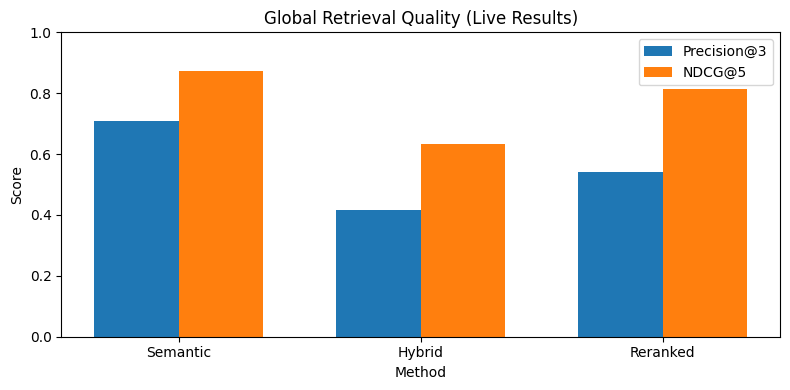

In [6]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["semantic", "hybrid", "reranked"]
labels = [m.title() for m in methods]
precision_3 = [METRIC_RESULTS[m]["global"]["mean_p@3"] for m in methods]
ndcg_5 = [METRIC_RESULTS[m]["global"]["mean_ndcg@5"] for m in methods]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, precision_3, width, label="Precision@3")
ax.bar(x + width / 2, ndcg_5, width, label="NDCG@5")
ax.set_xlabel("Method")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_title("Global Retrieval Quality (Live Results)")
plt.tight_layout()
plt.show()

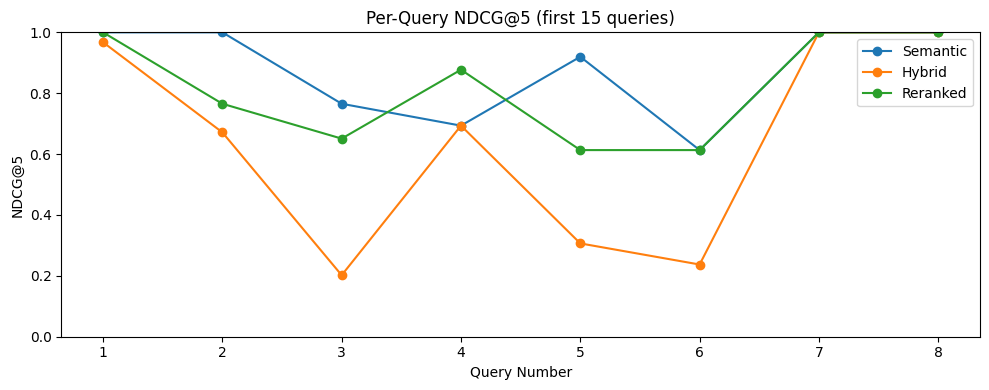

,qid,semantic,hybrid,reranked
0,1,1.000000,0.967468,1.000000
1,2,1.000000,0.671386,0.765361
2,3,0.765361,0.202107,0.650821
3,4,0.693426,0.693426,0.877215
4,5,0.919721,0.306574,0.613147
5,6,0.613147,0.237198,0.613147
6,7,1.000000,1.000000,1.000000
7,8,1.000000,1.000000,1.000000


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

sem_df = pd.DataFrame(METRIC_RESULTS["semantic"]["per_query"])[["qid", "ndcg@5"]].rename(columns={"ndcg@5": "semantic"})
hyb_df = pd.DataFrame(METRIC_RESULTS["hybrid"]["per_query"])[["qid", "ndcg@5"]].rename(columns={"ndcg@5": "hybrid"})
rer_df = pd.DataFrame(METRIC_RESULTS["reranked"]["per_query_rows"])[["qid", "ndcg@5"]].rename(columns={"ndcg@5": "reranked"})

plot_df = sem_df.merge(hyb_df, on="qid").merge(rer_df, on="qid").sort_values("qid")
plot_df = plot_df.head(15)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["qid"], plot_df["semantic"], marker="o", label="Semantic")
ax.plot(plot_df["qid"], plot_df["hybrid"], marker="o", label="Hybrid")
ax.plot(plot_df["qid"], plot_df["reranked"], marker="o", label="Reranked")
ax.set_xlabel("Query Number")
ax.set_ylabel("NDCG@5")
ax.set_ylim(0, 1)
ax.set_title("Per-Query NDCG@5 (first 15 queries)")
ax.legend()
plt.tight_layout()
plt.show()

plot_df

,modality,p@3,ndcg@5,method
3,code,0.166667,0.271886,Hybrid
6,code,0.333333,0.613147,Reranked
0,code,0.500000,0.766434,Semantic
4,image,0.666667,1.000000,Hybrid
7,image,0.666667,1.000000,Reranked
1,image,0.666667,1.000000,Semantic
5,text,0.416667,0.633597,Hybrid
8,text,0.583333,0.823349,Reranked
2,text,0.833333,0.864697,Semantic


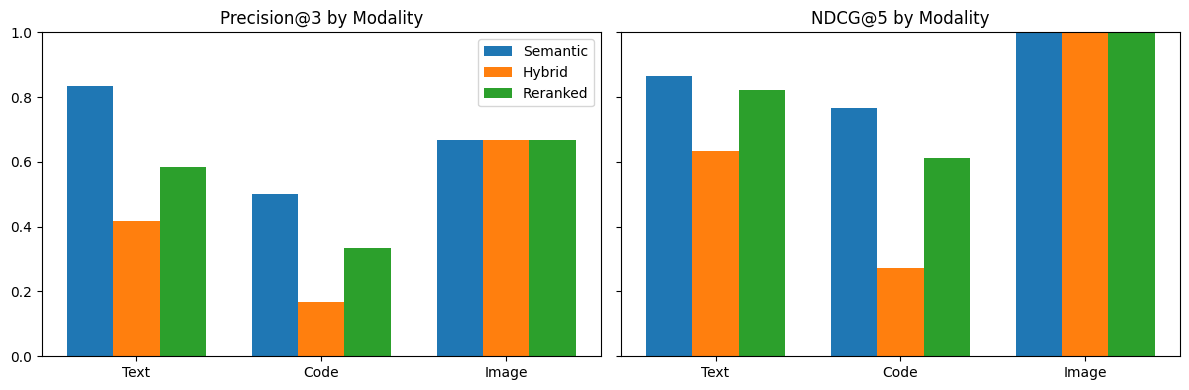

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

methods = ["semantic", "hybrid", "reranked"]
rows = []
for method in methods:
    if method == "reranked":
        df = pd.DataFrame(METRIC_RESULTS[method]["per_query_rows"])
    else:
        df = pd.DataFrame(METRIC_RESULTS[method]["per_query"])
    agg = df.groupby("modality", as_index=False)[["p@3", "ndcg@5"]].mean()
    agg["method"] = method.title()
    rows.append(agg)

mod_df = pd.concat(rows, ignore_index=True)
mod_df = mod_df.sort_values(["modality", "method"])
display(mod_df)

modalities = ["text", "code", "image"]
x = np.arange(len(modalities))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, method in enumerate(["Semantic", "Hybrid", "Reranked"]):
    vals = [
        mod_df[(mod_df["modality"] == m) & (mod_df["method"] == method)]["p@3"].mean()
        for m in modalities
    ]
    axes[0].bar(x + (i - 1) * width, vals, width, label=method)
axes[0].set_title("Precision@3 by Modality")
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.title() for m in modalities])
axes[0].set_ylim(0, 1)
axes[0].legend()

for i, method in enumerate(["Semantic", "Hybrid", "Reranked"]):
    vals = [
        mod_df[(mod_df["modality"] == m) & (mod_df["method"] == method)]["ndcg@5"].mean()
        for m in modalities
    ]
    axes[1].bar(x + (i - 1) * width, vals, width, label=method)
axes[1].set_title("NDCG@5 by Modality")
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.title() for m in modalities])
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## RAG Demo

In [9]:
import pandas as pd

method_label = {"semantic": "Semantic", "hybrid": "Hybrid", "reranked": "Reranked"}
metrics = ["mean_p@3", "mean_r@5", "mean_ndcg@5", "mean_mrr"]

summary_rows = []
for metric in metrics:
    scores = {m: METRIC_RESULTS[m]["global"][metric] for m in ["semantic", "hybrid", "reranked"]}
    best_method = max(scores, key=scores.get)
    summary_rows.append(
        {
            "Metric": metric.replace("mean_", "").upper(),
            "Best Method": method_label[best_method],
            "Score": round(scores[best_method], 4),
        }
    )

pd.DataFrame(summary_rows)

,Metric,Best Method,Score
0,P@3,Semantic,0.7083
1,R@5,Semantic,0.8958
2,NDCG@5,Semantic,0.8740
3,MRR,Reranked,1.0000


In [10]:
import json
import re
from pathlib import Path

from config.settings import get_path

data_dir = Path(PROJECT_ROOT) / get_path("data") / "processed"
text_chunks = json.loads((data_dir / "chunked_text.json").read_text(encoding="utf-8"))
code_chunks = json.loads((data_dir / "chunked_code.json").read_text(encoding="utf-8"))
image_meta = json.loads((data_dir / "image_metadata.json").read_text(encoding="utf-8"))

demo_queries = [
    (
        "Find two filing passages that jointly discuss supplier concentration risk and trade restriction exposure.",
        "text",
    ),
    (
        "Locate the code paths where backtest performance is computed using drawdown and Sharpe-style metrics.",
        "code",
    ),
    (
        "Which image shows an ROC curve used for classifier evaluation?",
        "image",
    ),
]

def _tokens(s: str) -> set[str]:
    return set(re.findall(r"[a-zA-Z0-9_]+", s.lower()))

def _top_hits(query: str, modality: str, k: int = 3):
    qtok = _tokens(query)

    if modality == "text":
        scored = []
        for r in text_chunks:
            txt = r.get("text", "")
            score = len(qtok & _tokens(txt))
            if score > 0:
                scored.append((score, r["chunk_id"], txt))
        scored.sort(key=lambda x: x[0], reverse=True)
        return scored[:k]

    if modality == "code":
        scored = []
        for r in code_chunks:
            code = r.get("code", "")
            score = len(qtok & _tokens(code))
            if score > 0:
                scored.append((score, r["chunk_id"], code))
        scored.sort(key=lambda x: x[0], reverse=True)
        return scored[:k]

    scored = []
    for r in image_meta:
        caption = r.get("caption", "")
        src = r.get("source_file", "")
        searchable = f"{caption} {Path(src).name}"
        score = len(qtok & _tokens(searchable))
        if score > 0:
            scored.append((score, r["doc_id"], searchable))
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:k]

for i, (query, modality) in enumerate(demo_queries, start=1):
    hits = _top_hits(query, modality, k=3)

    print(f"{i}. {query} ({modality})")

    if not hits:
        print("  no matches\n")
        continue

    for score, cid, txt in hits:
        snippet = txt[:140].replace("\n", " ").strip()
        print(f"  - {cid}: {snippet}...")
    
    print()

1. Find two filing passages that jointly discuss supplier concentration risk and trade restriction exposure. (text)
  - text_011: A principled approach to choosing epsilon uses the k-distance graph. For each point in the dataset, compute its distance to its k-th nearest...
  - text_077: A principled approach to choosing epsilon uses the k-distance graph. For each point in the dataset, compute its distance to its k-th nearest...
  - text_143: A principled approach to choosing epsilon uses the k-distance graph. For each point in the dataset, compute its distance to its k-th nearest...

2. Locate the code paths where backtest performance is computed using drawdown and Sharpe-style metrics. (code)
  - code_036: def plot_decision_boundary(clf, X, y, C: float):     """     Plot class assignments, the decision boundary, and probability contours.      T...
  - code_080: def plot_decision_boundary(clf, X, y, C: float):     """     Plot class assignments, the decision boundary, and probability c